In [1]:
# (Save the notebook as decision_tree_iris.ipynb)
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn import datasets, tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# Load Iris dataset (built into scikit-learn, no upload needed)
iris = datasets.load_iris(as_frame=True)
iris_df = iris.frame
iris_df['Species'] = iris_df['target'].map(dict(enumerate(iris.target_names)))
iris_df = iris_df.drop(columns=['target'])
print(iris_df.head())


   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  Species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  


Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



<Figure size 600x500 with 0 Axes>

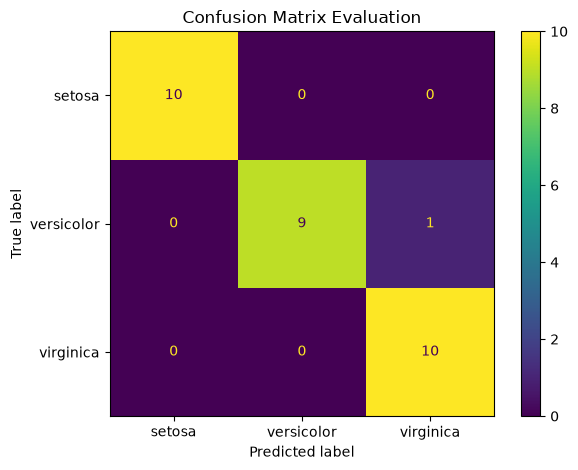

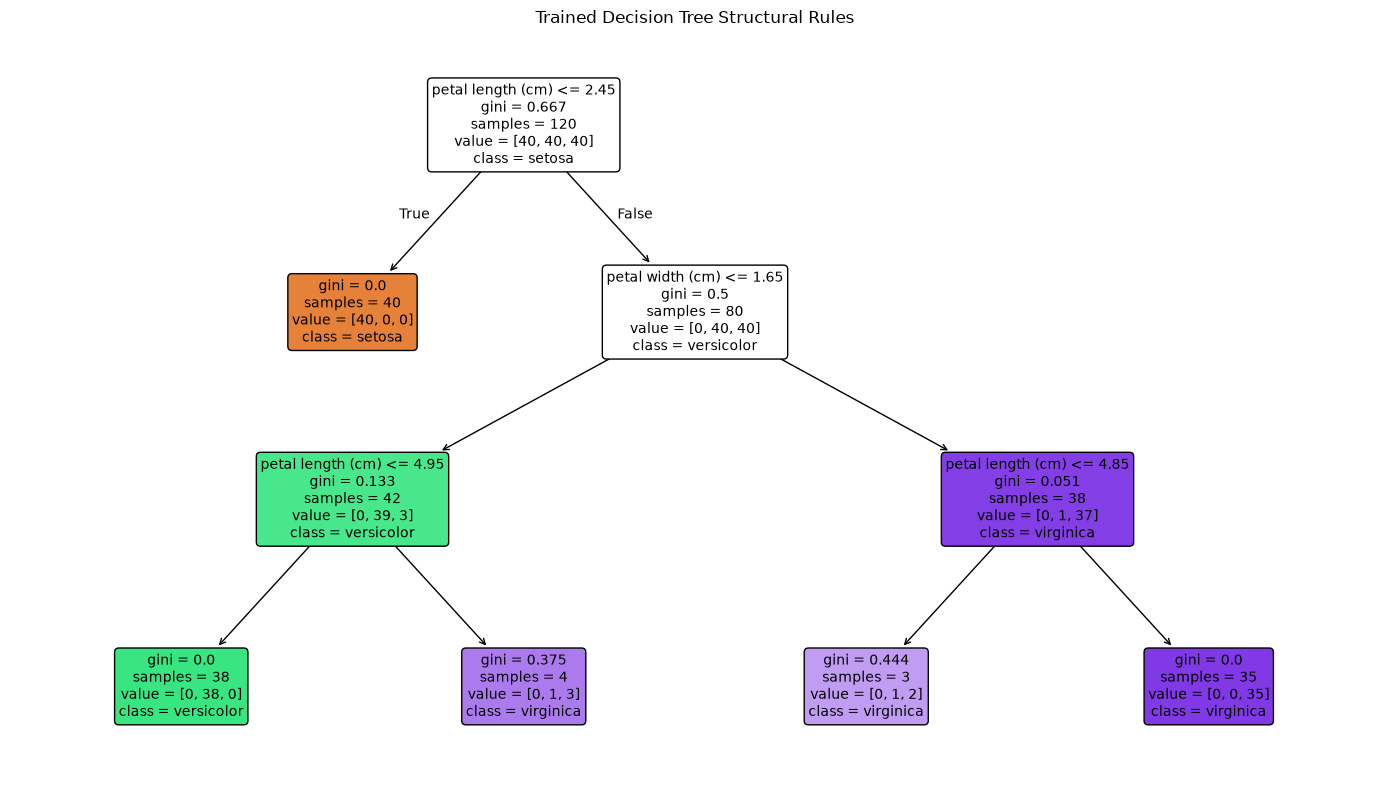

In [2]:
# =====================================================================
# STEP 2: Split Data, Train Decision Tree, and Generate Metrics
# =====================================================================

# Split features (X) and target label (y)
X = iris_df.drop(columns=['Species'])
y = iris_df['Species']

# Split into 80% training and 20% testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Initialize and train the Decision Tree Classifier
clf = tree.DecisionTreeClassifier(max_depth=3, random_state=42)
clf.fit(X_train, y_train)

# Make predictions on the test dataset
y_pred = clf.predict(X_test)

# Print out the text-based classification report matrix
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

# =====================================================================
# STEP 3: Plot and Save the Confusion Matrix
# =====================================================================
plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(
    clf, X_test, y_test, display_labels=iris.target_names, cmap='viridis'
)
plt.title("Confusion Matrix Evaluation")
plt.tight_layout()
plt.show()

# =====================================================================
# STEP 4: Plot and Visualise the Decision Tree Structure
# =====================================================================
plt.figure(figsize=(14, 8))
tree.plot_tree(
    clf,
    feature_names=X.columns.tolist(),
    class_names=iris.target_names.tolist(),
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Trained Decision Tree Structural Rules")
plt.tight_layout()
plt.show()
